# AnalizadorSolar — guía de uso (Tamaulipas 2024)

Recorrido práctico de la clase `AnalizadorSolar` (`Utils/analizador_datos.py`) sobre el
dataset consolidado **NSRDB de Tamaulipas 2024**.

Cubre: lectura, filtros, estadísticas, **integridad de datos**, índice de claridad `kt`,
**comparación inter-anual (2024 vs 2023)**, gráficas, **mapas por nodo** y **exportación**.

> Documentación completa: `Utils/README_analizador.md`. Referencia de columnas y flags:
> `Data/Tamaulipas/REFERENCIA_NSRDB.md`.

## 0. Preparación

Ejecutar desde la raíz del proyecto. `%matplotlib inline` hace que las figuras que devuelven
los métodos se muestren bajo cada celda.

In [1]:
%matplotlib inline
from Utils.analizador_datos import AnalizadorSolar

a = AnalizadorSolar(
    parquet="Data/Puerto_Rico/2024/Finales/completo/dataset_puerto_rico_completo_24h_2024.parquet",
    metadata="Data/Puerto_Rico/2024/metadata_nodos_2024.csv",
    anio=2024,
    region="Puerto_Rico"
)   # Puerto Rico 2024 (consolidado estándar)
a

> **Caché de lectura** (activa por defecto): las llamadas con el **mismo filtro**
> reutilizan la lectura del disco —aunque pidan otras columnas—, así re-ejecutar
> celdas y los análisis encadenados van mucho más rápido (p.ej. repetir
> `a.integridad(mes=2)` baja de ~11 s a ~1.5 s). Se desactiva con
> `AnalizadorSolar(..., usar_cache=False)` y se vacía con `a.limpiar_cache()`.

## 1. ¿Qué hay dentro? — `info()`

Tamaño en disco, nº de filas, nodos, días, rango temporal y la lista de columnas con sus
unidades. Las marcadas como `FLAG` son banderas de calidad.

In [2]:
info = a.info()
print('\nVariables analizables:', a.variables)

=== dataset_pr_completo_24h_2024.parquet ===
  Tamaño en disco : 123.4 MB
  Filas           : 6,623,136
  Nodos           : 754
  Días distintos  : 366
  Rango temporal  : 2024-01-01 00:00:00  ->  2024-12-31 23:00:00
  Columnas (31):
      nodo_id                  clave
      datetime                 clave
      year                     clave
      month                    clave
      day                      clave
      hour                     clave
      ghi                      W/m²
      dni                      W/m²
      dhi                      W/m²
      clearsky_ghi             W/m²
      clearsky_dni             W/m²
      clearsky_dhi             W/m²
      solar_zenith_angle       °
      cloud_type               FLAG
      cloud_fill_flag          FLAG
      fill_flag                FLAG
      temperature              °C
      dew_point                °C
      relative_humidity        %
      pressure                 mbar
      precipitable_water       cm
      wind_speed

## 2. Integridad de los datos — `integridad()`

El informe clave de calidad. Comprueba completitud (filas reales vs esperadas), duplicados,
nodos incompletos, nulos, valores fuera de rango físico, **% de datos rellenados**
(`fill_flag != 0`) y anomalías físicas (GHI>clearsky, GHI/DNI=0 de día, GHI negativo).

Con `graficar=True` añade un panel con la distribución de las 3 flags y la completitud por nodo.

In [3]:
# Integridad de TODO el año (puede tardar unos segundos: lee ~38 M filas):
rep = a.integridad()

========== INTEGRIDAD — dataset_pr_completo_24h_2024.parquet ==========
Completitud : 6,623,136 / 6,623,136 filas (100.0%)  | nodos=754 días=366 horas/día=24
Duplicados  : 0
Nodos incompletos: 0
Relleno (fill_flag!=0): 494,639 (7.468%)
Nulos       : ninguno
Fuera de rango físico: ninguno
Anomalías físicas:
   GHI > clearsky_ghi : 0
   GHI = 0 de día     : 0
   DNI = 0 de día     : 129,538 (normal con cielo cubierto)
   GHI negativo       : 0
⏱ 0.7 s


========== INTEGRIDAD — dataset_pr_completo_24h_2024.parquet ==========
Completitud : 524,784 / 524,784 filas (100.0%)  | nodos=754 días=29 horas/día=24
Duplicados  : 0
Nodos incompletos: 0
Relleno (fill_flag!=0): 34,011 (6.481%)
Nulos       : ninguno
Fuera de rango físico: ninguno
Anomalías físicas:
   GHI > clearsky_ghi : 0
   GHI = 0 de día     : 0
   DNI = 0 de día     : 13,229 (normal con cielo cubierto)
   GHI negativo       : 0
⏱ 0.1 s


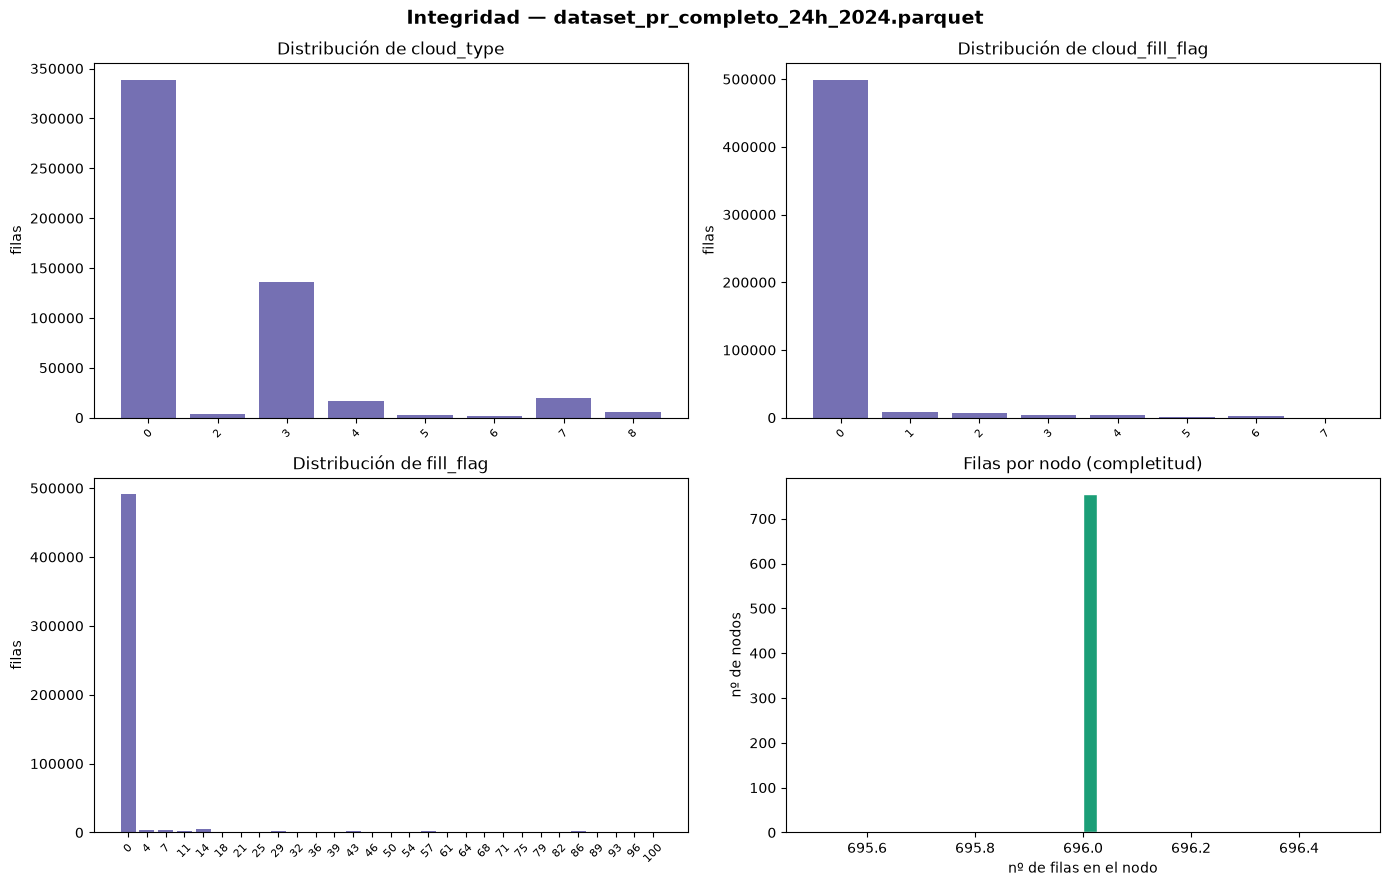

In [4]:
# Integridad de un periodo concreto + gráficas (febrero, incluye el 29 bisiesto):
rep_feb = a.integridad(mes=2, graficar=True)

### 2.1 Filas con anomalías — `anomalias()`

`integridad()` cuenta los problemas; `anomalias()` devuelve las **filas** concretas
(un DataFrame por tipo) para poder inspeccionarlas o exportarlas.

In [5]:
# `anomalias()` devuelve las FILAS concretas (no solo el conteo de integridad):
an = a.anomalias()
# Inspeccionar un tipo en particular (p.ej. presión fuera de rango físico):
an['rango_pressure'].head() if 'rango_pressure' in an else 'sin presión fuera de rango'

===== ANOMALÍAS — dataset_pr_completo_24h_2024.parquet =====
  dni_cero_de_dia       :    1,000 filas (primeras 1000)


'sin presión fuera de rango'

**Presión calibrada por elevación.** El chequeo de `pressure` se compara contra la
presión esperada por la **altitud** de cada nodo (fórmula barométrica), no contra un
rango plano. Así los nodos de montaña no se marcan como anómalos y sí se detectan
desviaciones reales. Ajustable con `tol_presion` al crear el analizador.

In [23]:
from Utils.analizador_datos import presion_barometrica
# El chequeo de presión se calibra por la ALTITUD de cada nodo (no un rango plano):
# un nodo de montaña con presión baja es normal y ya no se marca como anómalo.
n = 100
print(f'Nodo {n}: msnm={a.elev.loc[n]:.0f} m  ->  presión esperada '
      
      f'{presion_barometrica(a.elev.loc[n]):.0f} mbar (±{a.tol_presion:.0f})')

AttributeError: 'NoneType' object has no attribute 'loc'

## 3. Banderas de calidad — `flags()`

Distribución (conteo y %) de `cloud_type`, `cloud_fill_flag` y `fill_flag`. `cloud_type` viene
con su descripción legible.

In [8]:
tablas = a.flags(dia='2024-02-29')
tablas['cloud_type']

,codigo,conteo,%,desc
0,0,17786,98.287,Clear
1,2,94,0.519,Fog
2,3,216,1.194,Water


## 4. Estadísticas

- `estadisticas(...)` → `describe` (con percentiles) + nulos por variable.
- `resumen_nodos(...)` → estadísticos **por nodo** (con coordenadas), para detectar nodos atípicos.

In [9]:
a.estadisticas(['ghi', 'dni', 'temperature', 'relative_humidity'], mes=2)

,count,mean,std,min,5%,25%,50%,75%,95%,max,nulos,%nulos
ghi,524784.0,201.010279,289.983385,0.00,0.000000,0.000000,0.000000,360.000000,848.000000,990.000000,0,0.0
dni,524784.0,226.507773,339.832350,0.00,0.000000,0.000000,0.000000,460.000000,920.000000,1029.000000,0,0.0
temperature,524784.0,25.991009,2.090803,16.40,22.200001,24.799999,26.200001,27.400000,29.200001,31.799999,0,0.0
relative_humidity,524784.0,78.010780,10.883605,37.75,59.349998,70.260002,79.080002,85.629997,95.370003,100.000000,0,0.0


In [10]:
res = a.resumen_nodos('ghi', mes=2)
res.head()

,nodo_id,mean,std,min,max,latitude,longitude
0,0,220.285920,304.177684,0,948,17.65,-64.90
1,1,221.147989,305.655083,0,948,17.65,-64.86
2,2,222.119253,306.662163,0,948,17.65,-64.82
3,3,218.169540,304.199007,0,949,17.69,-64.90
4,4,220.656609,306.389616,0,962,17.69,-64.86


## 5. Filtros y extracción de subconjuntos — `filtrar()`

Todos los métodos aceptan los mismos filtros: `nodos`, `mes`, `dia`, `hora`, `rango_fechas`,
`solo_diurno`, `cloud_type`, `query` (avanzado) y `con_kt`.

La carga es perezosa: los filtros baratos (nodo/mes/día/hora) se empujan a pyarrow y solo se lee
del disco lo necesario.

In [11]:
# 3 nodos, 29 de febrero, solo horas con sol, con la columna derivada kt:
df = a.filtrar(nodos=[0, 1, 2], dia='2024-02-29', solo_diurno=True,
               columnas=['nodo_id', 'datetime', 'ghi', 'dni', 'kt'])
df.head()

,nodo_id,datetime,ghi,dni,kt
0,0,2024-02-29 11:00:00,151,520,0.986928
1,0,2024-02-29 12:00:00,395,771,1.000000
2,0,2024-02-29 13:00:00,604,804,0.972625
3,0,2024-02-29 14:00:00,800,923,1.000000
4,0,2024-02-29 15:00:00,846,736,0.924590


In [12]:
# Filtro avanzado con query + columnas legibles (cloud_type_desc, relleno):
df2 = a.filtrar(mes=6, query='ghi > 900',
                columnas=['nodo_id', 'datetime', 'ghi', 'cloud_type', 'fill_flag'])
a.decodificar(df2).head()

,nodo_id,datetime,ghi,cloud_type,fill_flag,cloud_type_desc,relleno
0,0,2024-06-01 15:00:00,902,0,0,Clear,False
1,0,2024-06-04 15:00:00,923,0,0,Clear,False
2,0,2024-06-04 16:00:00,906,0,0,Clear,False
3,0,2024-06-08 15:00:00,968,0,0,Clear,False
4,0,2024-06-08 16:00:00,985,0,0,Clear,False


## 6. Índice de claridad `kt` y clasificación de días

`kt = ghi / clearsky_ghi` (definido solo de día). Mide qué tan despejado estuvo el cielo:
`kt≈1` despejado, `kt` bajo = cubierto. Se usa como cualquier variable.

`clasificar_dias()` etiqueta cada día como **despejado / parcial / cubierto** según su `kt` medio diurno.

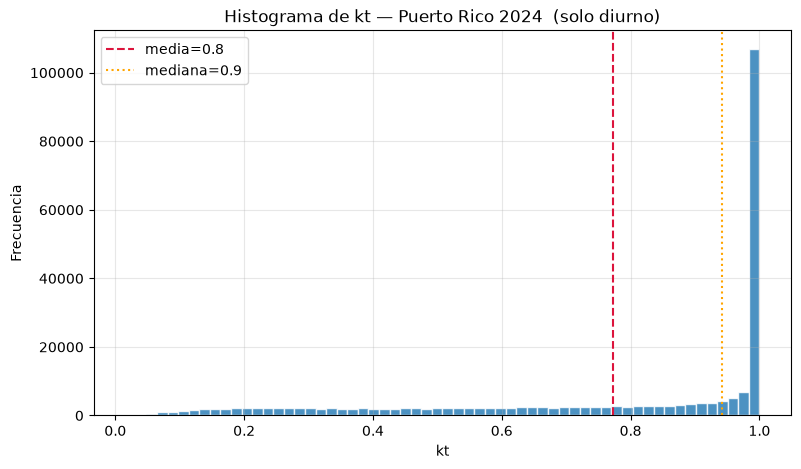

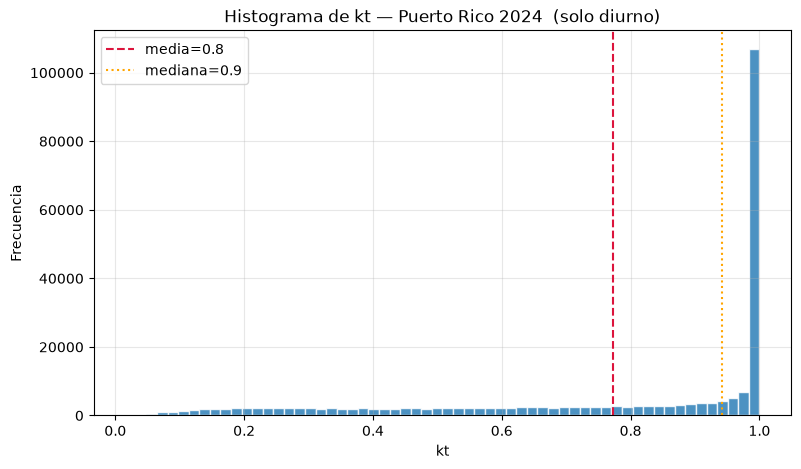

In [13]:
a.histograma('kt', solo_diurno=True, mes=2)

Días por categoría: {'despejado': 317, 'parcial': 45, 'cubierto': 4}


,month,day,kt_medio,categoria,fecha
0,1,1,0.877285,despejado,2024-01-01
1,1,2,0.965876,despejado,2024-01-02
2,1,3,0.970095,despejado,2024-01-03
3,1,4,0.877384,despejado,2024-01-04
4,1,5,0.891146,despejado,2024-01-05


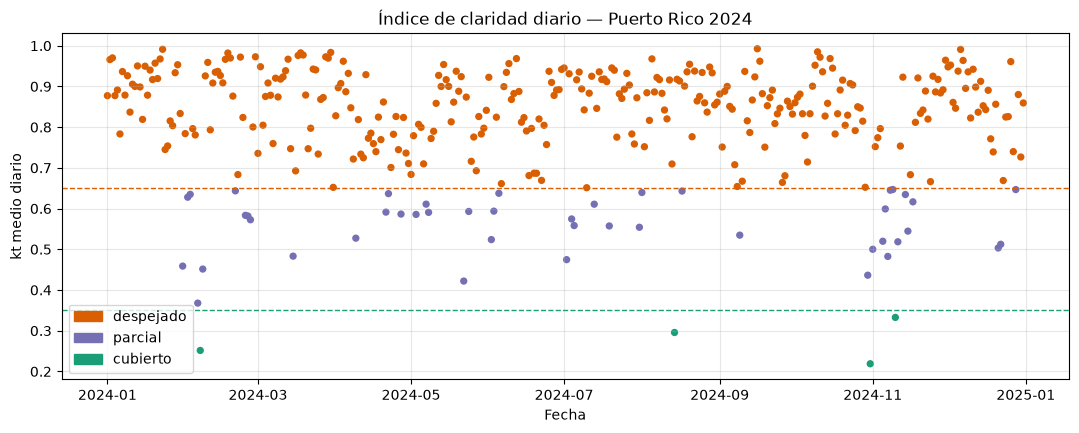

In [15]:
# clas = a.clasificar_dias(mes=2, graficar=True)
clas = a.clasificar_dias( graficar=True)
clas.head()

## 7. Gráficas

Todas devuelven el `Figure` (visible aquí). En consola/script añade `guardar='salida.png'`.

- `histograma` · `serie_temporal` · `perfil_diario` (perfil horario medio ±σ) · `correlaciones`.

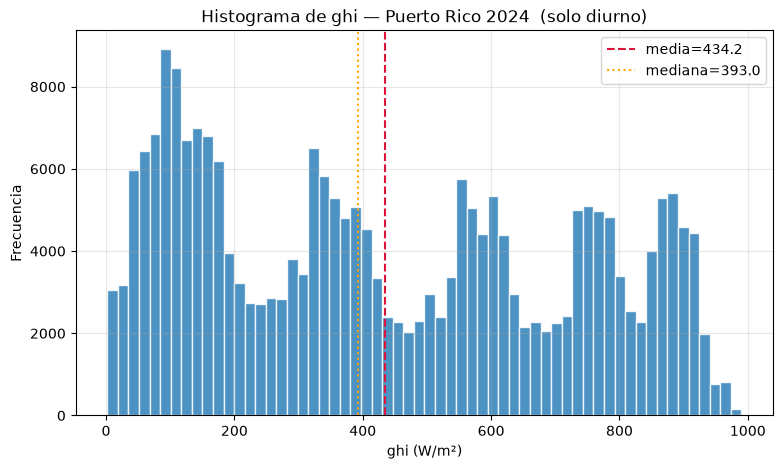

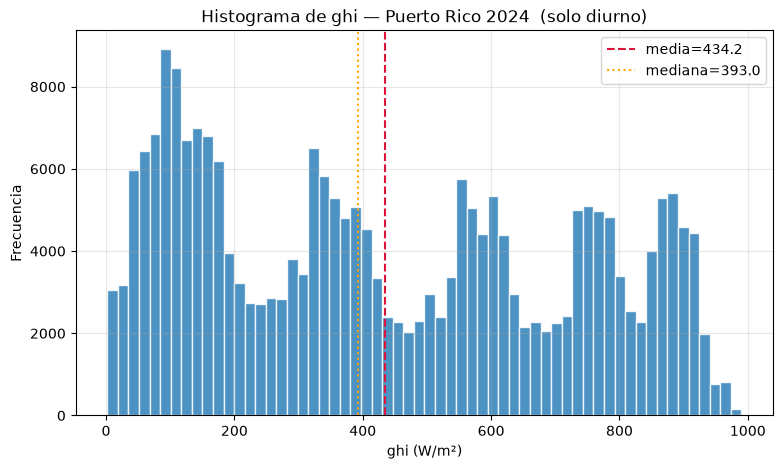

In [16]:
a.histograma('ghi', solo_diurno=True, mes=2)

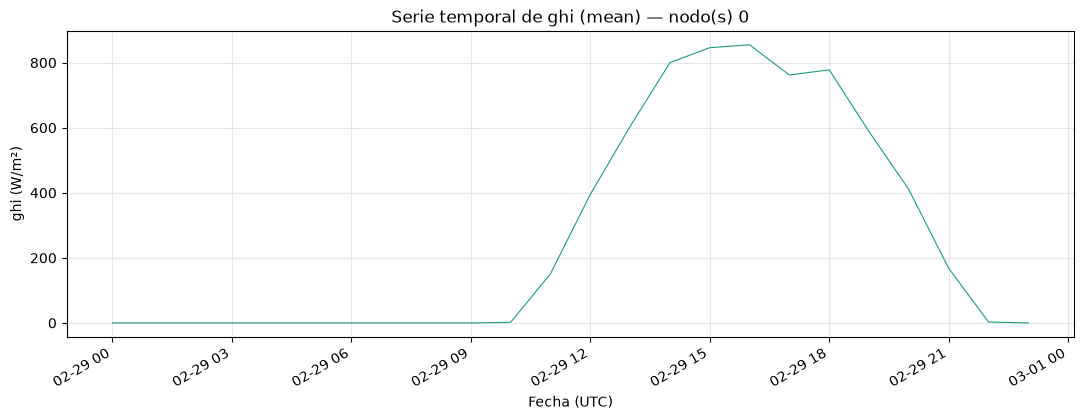

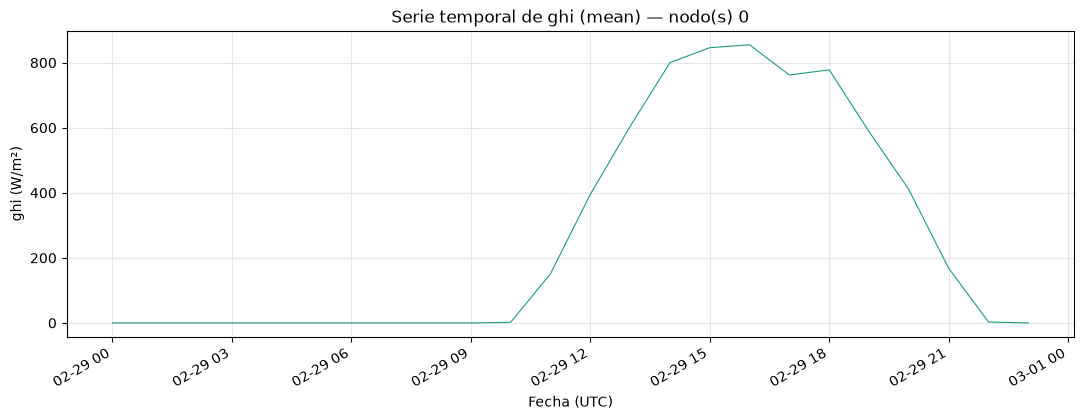

In [17]:
# Serie temporal de un nodo en un día (perfil real de GHI del 29-feb):
a.serie_temporal('ghi', nodos=0, dia='2024-02-29')

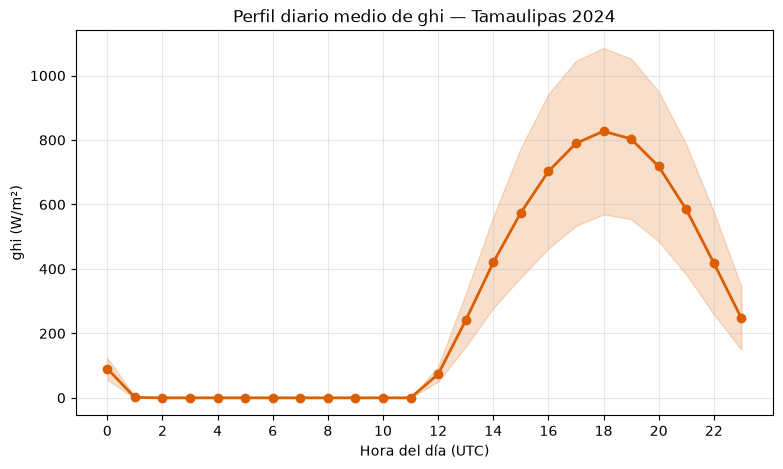

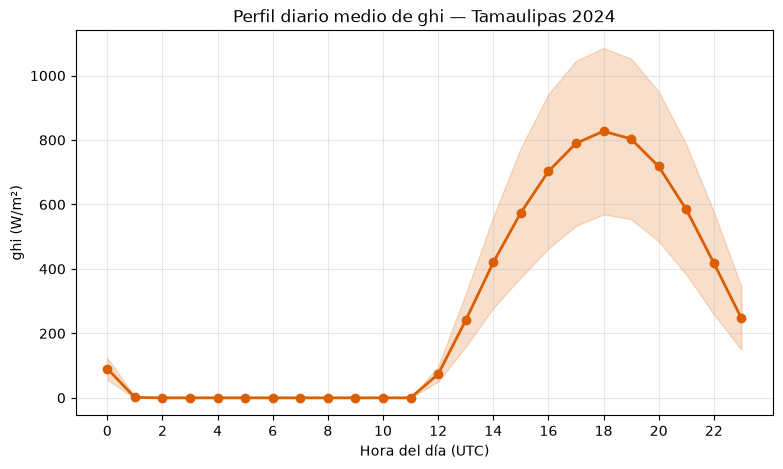

In [16]:
# Perfil diario medio de junio (curva horaria promedio con banda de ±1 desviación):
a.perfil_diario('ghi', mes=6)

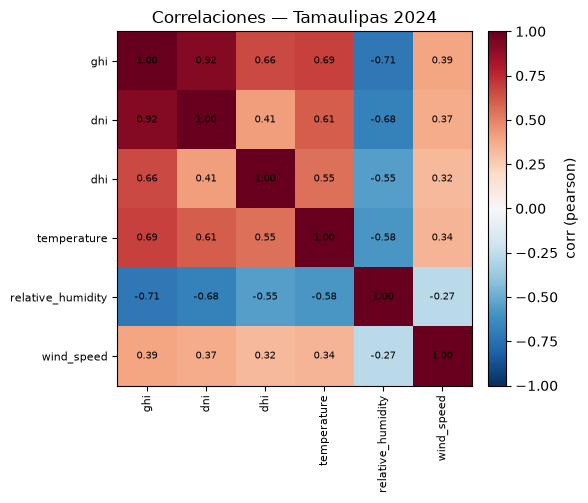

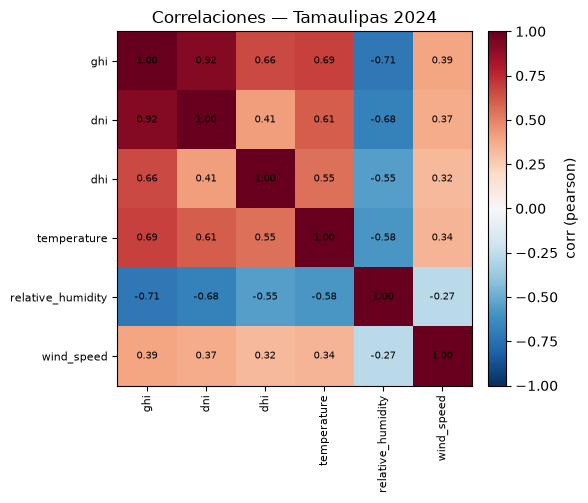

In [15]:
a.correlaciones(['ghi', 'dni', 'dhi', 'temperature', 'relative_humidity', 'wind_speed'], mes=2)

## 8. Comparación inter-anual (2024 vs 2023) — `comparar()`

- `por='mes'`  → una fila por mes, una columna por año (línea por año).
- `por='nodo'` → una fila por nodo con `delta` y `delta_%` (y coordenadas).
- `por='total'`→ un único valor agregado por año.

Acepta varios años: `a.comparar([2022, 2023], ...)`.

,2020,2021,2022,2023,2024
Enero,195.209014,206.004481,214.836991,198.732662,199.248599
Febrero,230.470414,234.818129,217.901758,226.072396,201.010279
Marzo,241.762058,265.583879,253.730805,263.273839,256.402761
Abril,278.029891,265.499289,262.686507,261.240202,243.763859
Mayo,273.131517,268.245224,262.180482,271.866604,253.505287
Junio,272.323707,243.402910,271.264965,275.446452,254.226494
Julio,258.835531,265.324971,258.690495,257.205164,251.008883
Agosto,267.135230,263.114884,258.494381,246.406074,258.328731
Septiembre,239.376009,246.423981,223.986621,250.207234,241.545778
Octubre,208.227766,221.214080,210.672339,211.177648,218.788178


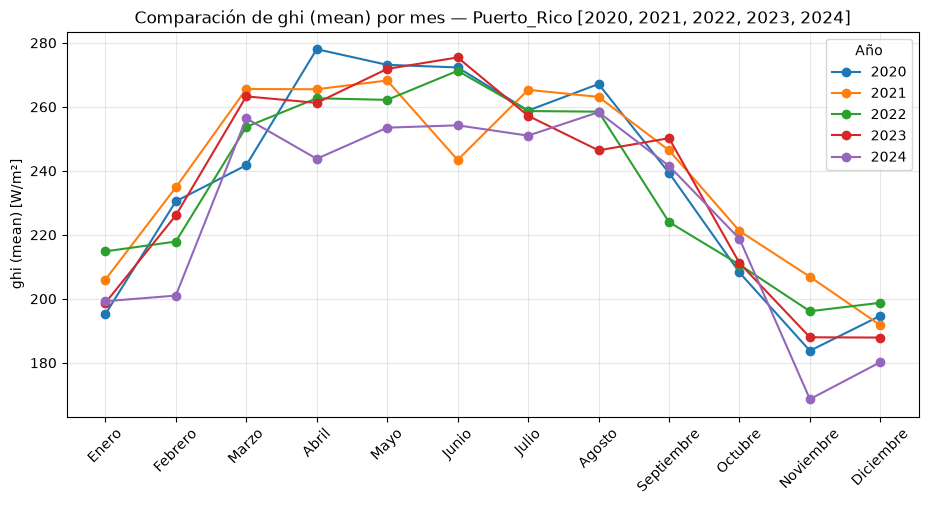

In [27]:
# GHI medio por mes, 2024 vs 2023:
comp_mes = a.comparar([2020, 2021, 2022, 2023], variable='ghi', por='mes', graficar=True)
comp_mes

,nodo_id,2023,2024,delta,delta_%,latitude,longitude
0,0,0.879793,0.835184,-0.044609,-5.07,17.65,-64.90
1,1,0.872511,0.836677,-0.035834,-4.11,17.65,-64.86
2,2,0.881823,0.839017,-0.042806,-4.85,17.65,-64.82
3,3,0.906048,0.833994,-0.072054,-7.95,17.69,-64.90
4,4,0.903674,0.838698,-0.064976,-7.19,17.69,-64.86


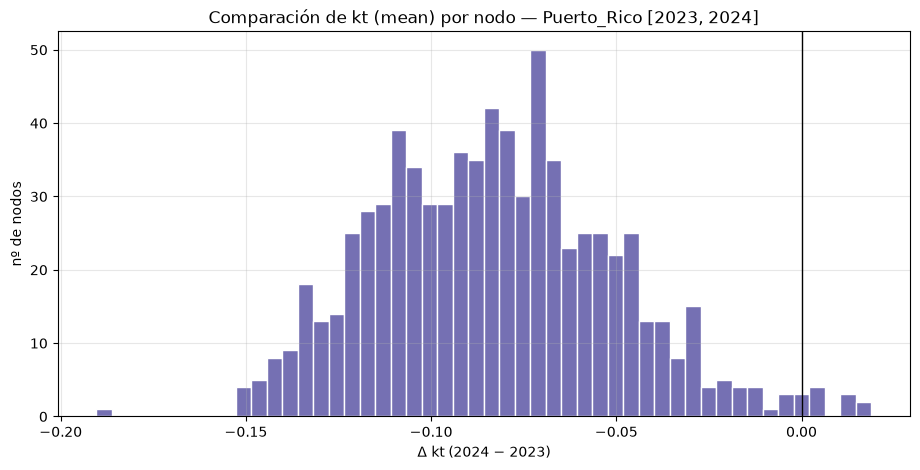

In [30]:
# Diferencia del índice de claridad por nodo en febrero (histograma de deltas):
comp_nodo = a.comparar([2023], variable='kt', por='nodo', mes=2, graficar=True)
comp_nodo.head()

In [33]:
# Valor agregado de todo el año:
a.comparar([2020, 2021, 2022, 2023], variable='ghi', por='total')

 anio        ghi
 2020 236.878651
 2021 239.889854
 2022 235.894526
 2023 236.463811
 2024 227.368290


,anio,ghi
0,2020,236.878651
1,2021,239.889854
2,2022,235.894526
3,2023,236.463811
4,2024,227.368290


## 9. Agregados temporales, recurso y estacionalidad

Bloque orientado al análisis del **recurso solar**:

- `resamplear(...)` → series horarias/diarias/mensuales. Con `agregacion='sum', factor=1/1000`
  da la **insolación** en kWh/m²/día. Con `por_nodo=True` devuelve una serie por nodo.
- `curva_duracion(...)` → curva de excedencia (qué irradiancia se supera en qué % del tiempo).
- `outliers_nodos(...)` → nodos atípicos por z-score o IQR, señalados sobre el mapa.
- `rosa_viento(...)` y `rosa_viento_12meses(...)` → rosa de los vientos (anual y por mes).
- `boxplot(...)` y `heatmap_mes_hora(...)` → estacionalidad y ciclo diario.

Insolación media de febrero: 4.82 kWh/m²/día


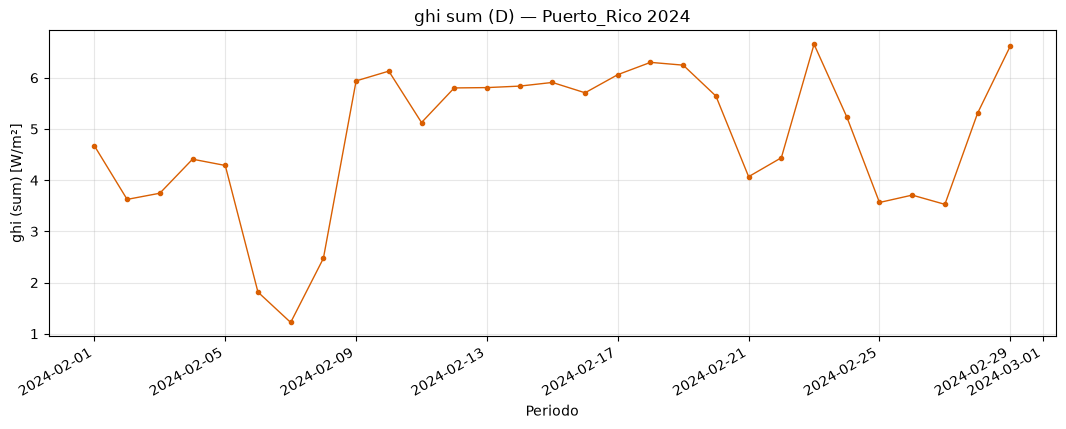

In [34]:
# Insolación: total diario de GHI en kWh/m²/día (suma horaria × 1/1000), febrero:
insol = a.resamplear('ghi', frecuencia='D', agregacion='sum', factor=1/1000,
                     mes=2, graficar=True)
print('Insolación media de febrero:', round(insol['ghi'].mean(), 2), 'kWh/m²/día')

,periodo,ghi
0,2024-01-01,199.248599
1,2024-02-01,201.010279
2,2024-03-01,256.402761
3,2024-04-01,243.763859
4,2024-05-01,253.505287
5,2024-06-01,254.226494
6,2024-07-01,251.008883
7,2024-08-01,258.328731
8,2024-09-01,241.545778
9,2024-10-01,218.788178


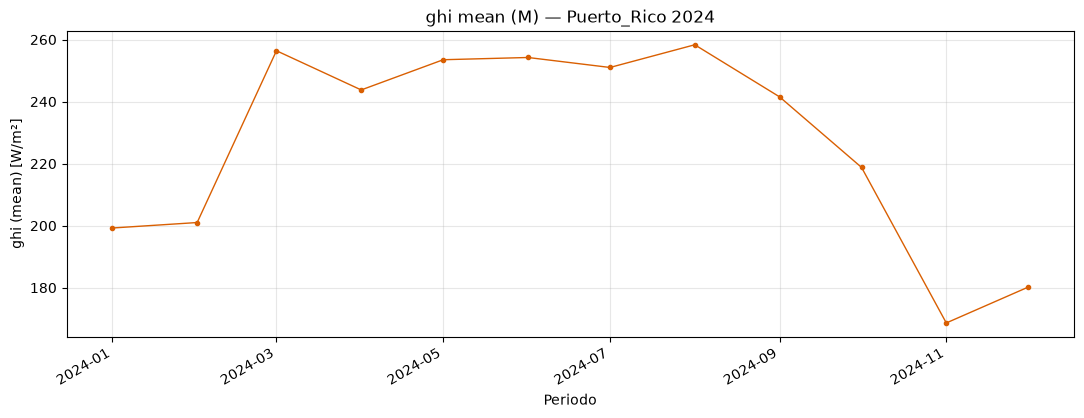

In [35]:
# GHI medio mensual de todo el año (un punto por mes):
a.resamplear('ghi', frecuencia='M', agregacion='mean', graficar=True)

,valor,excedencia_%
0,990,0.000412
1,990,0.000824
2,986,0.001236
3,986,0.001647
4,985,0.002059


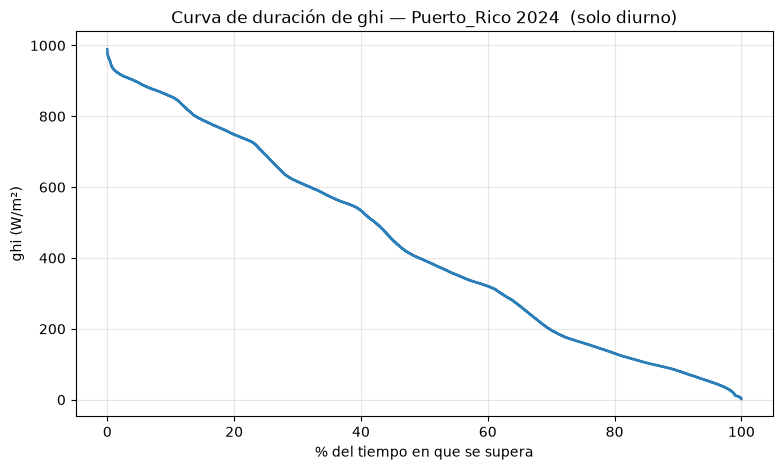

In [36]:
# Curva de duración del GHI diurno (qué valor se supera en qué % del tiempo):
dur = a.curva_duracion('ghi', solo_diurno=True, mes=2)
dur.head()

Outliers de ghi (mean) por nodo [zscore: |z| > 3.0]: 0 de 754 nodos


,nodo_id,mean,zscore,latitude,longitude


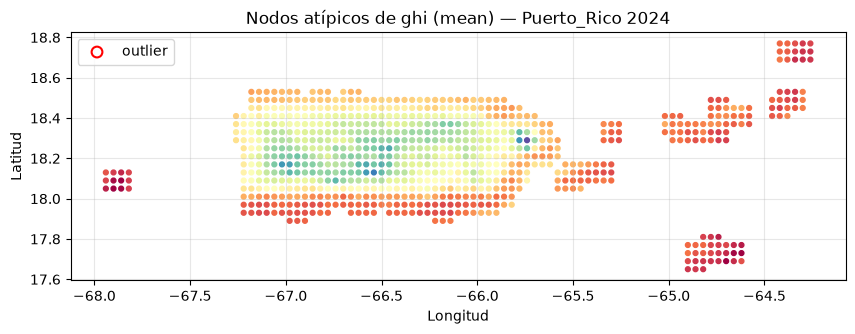

In [2]:
# Nodos atípicos según el GHI medio anual (z-score), señalados sobre el mapa:
out = a.outliers_nodos('ghi', metodo='zscore', umbral=3.0, graficar=True)
out[['nodo_id', 'mean', 'zscore', 'latitude', 'longitude']].head()

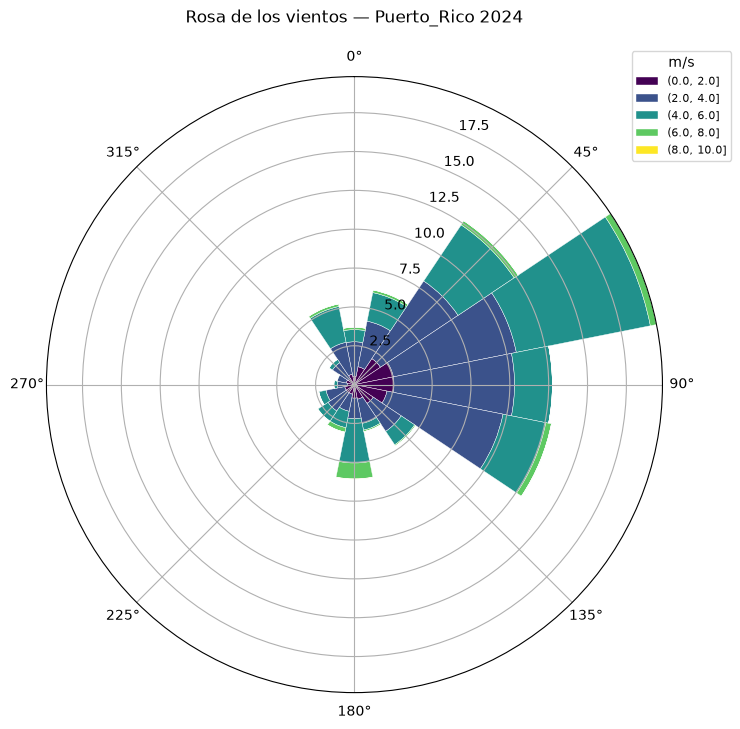

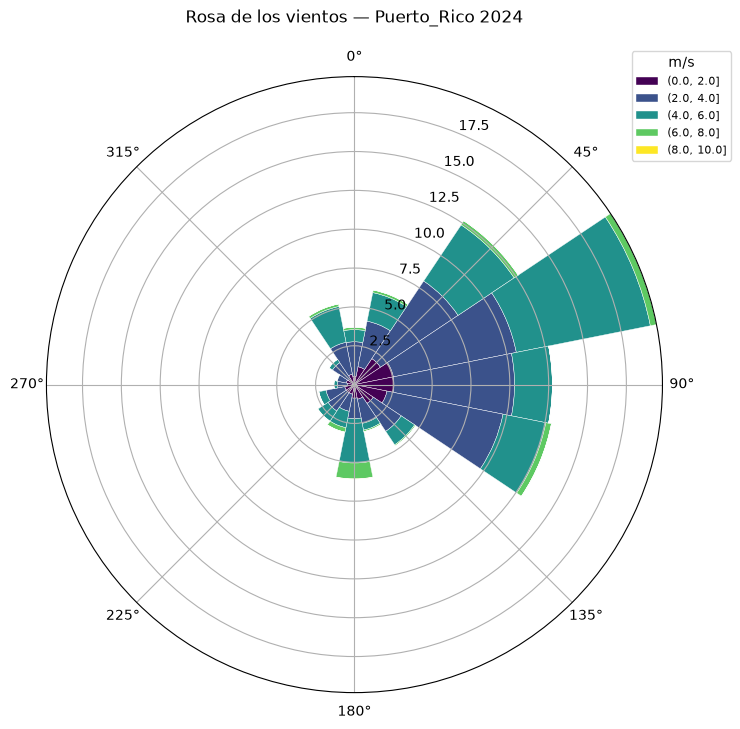

In [38]:
# Rosa de los vientos (dirección y velocidad del viento) de febrero:
a.rosa_viento(mes=2)

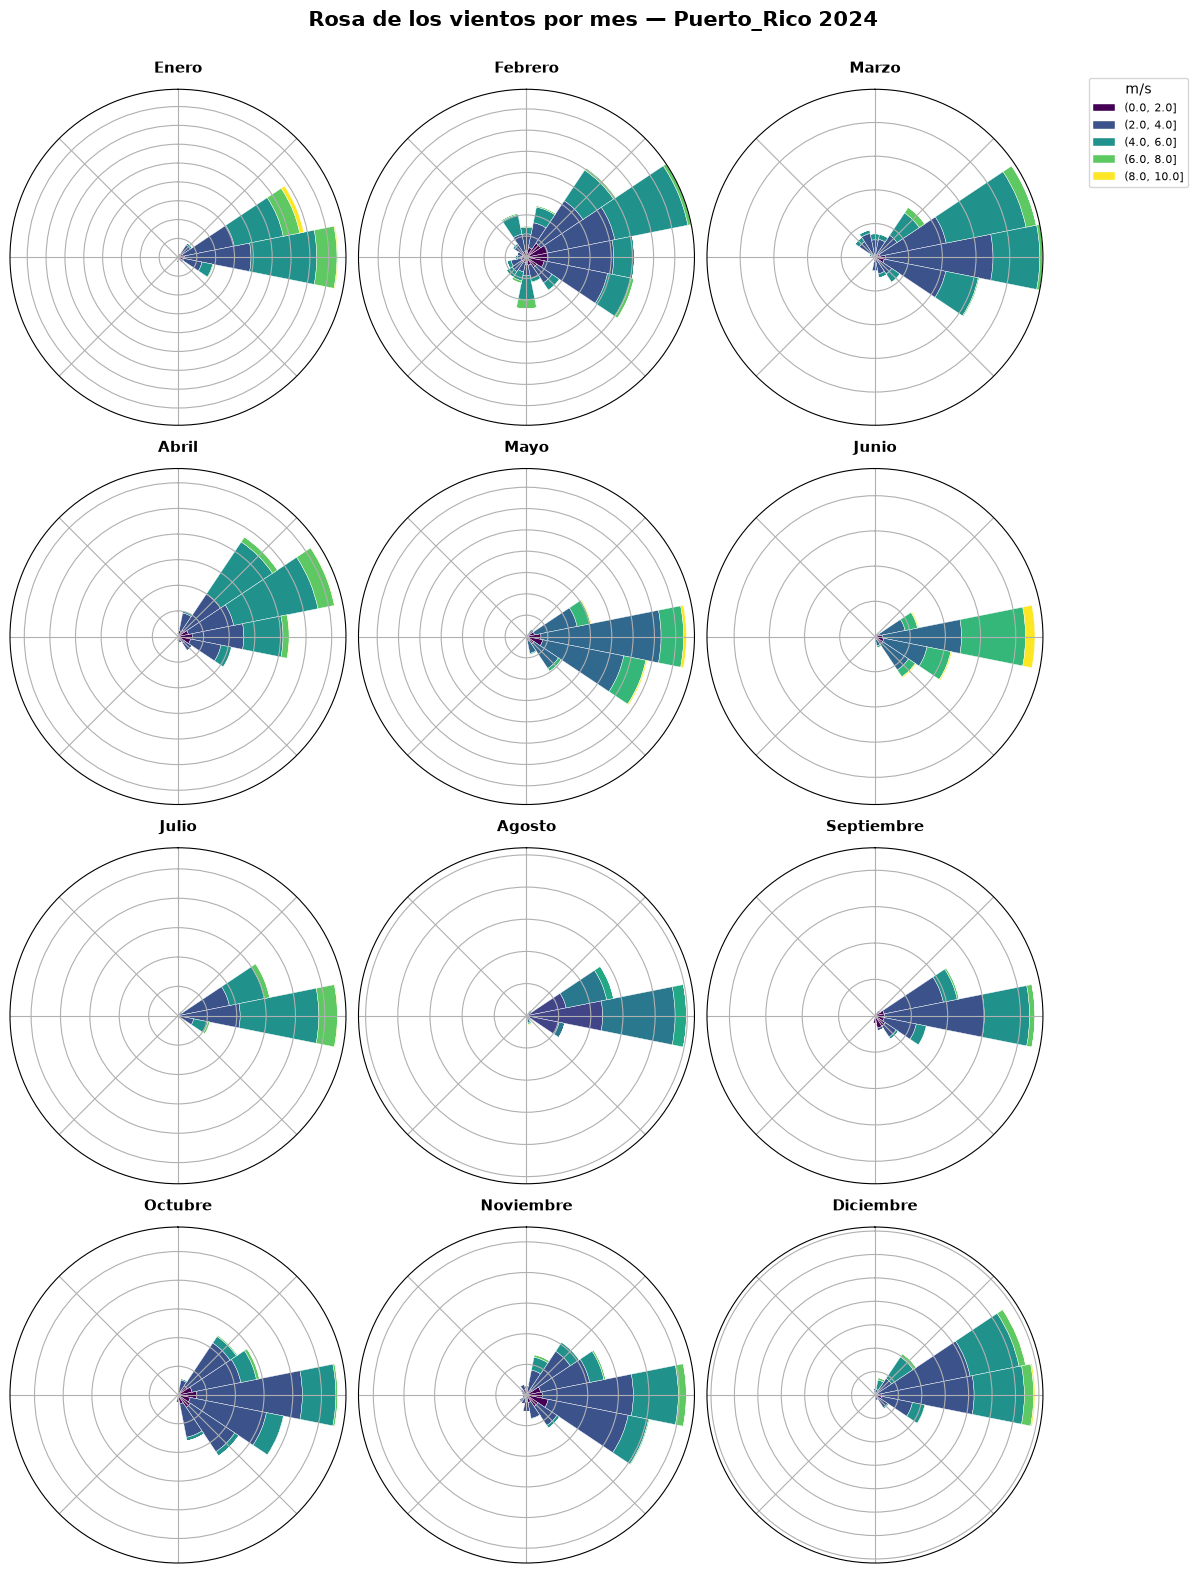

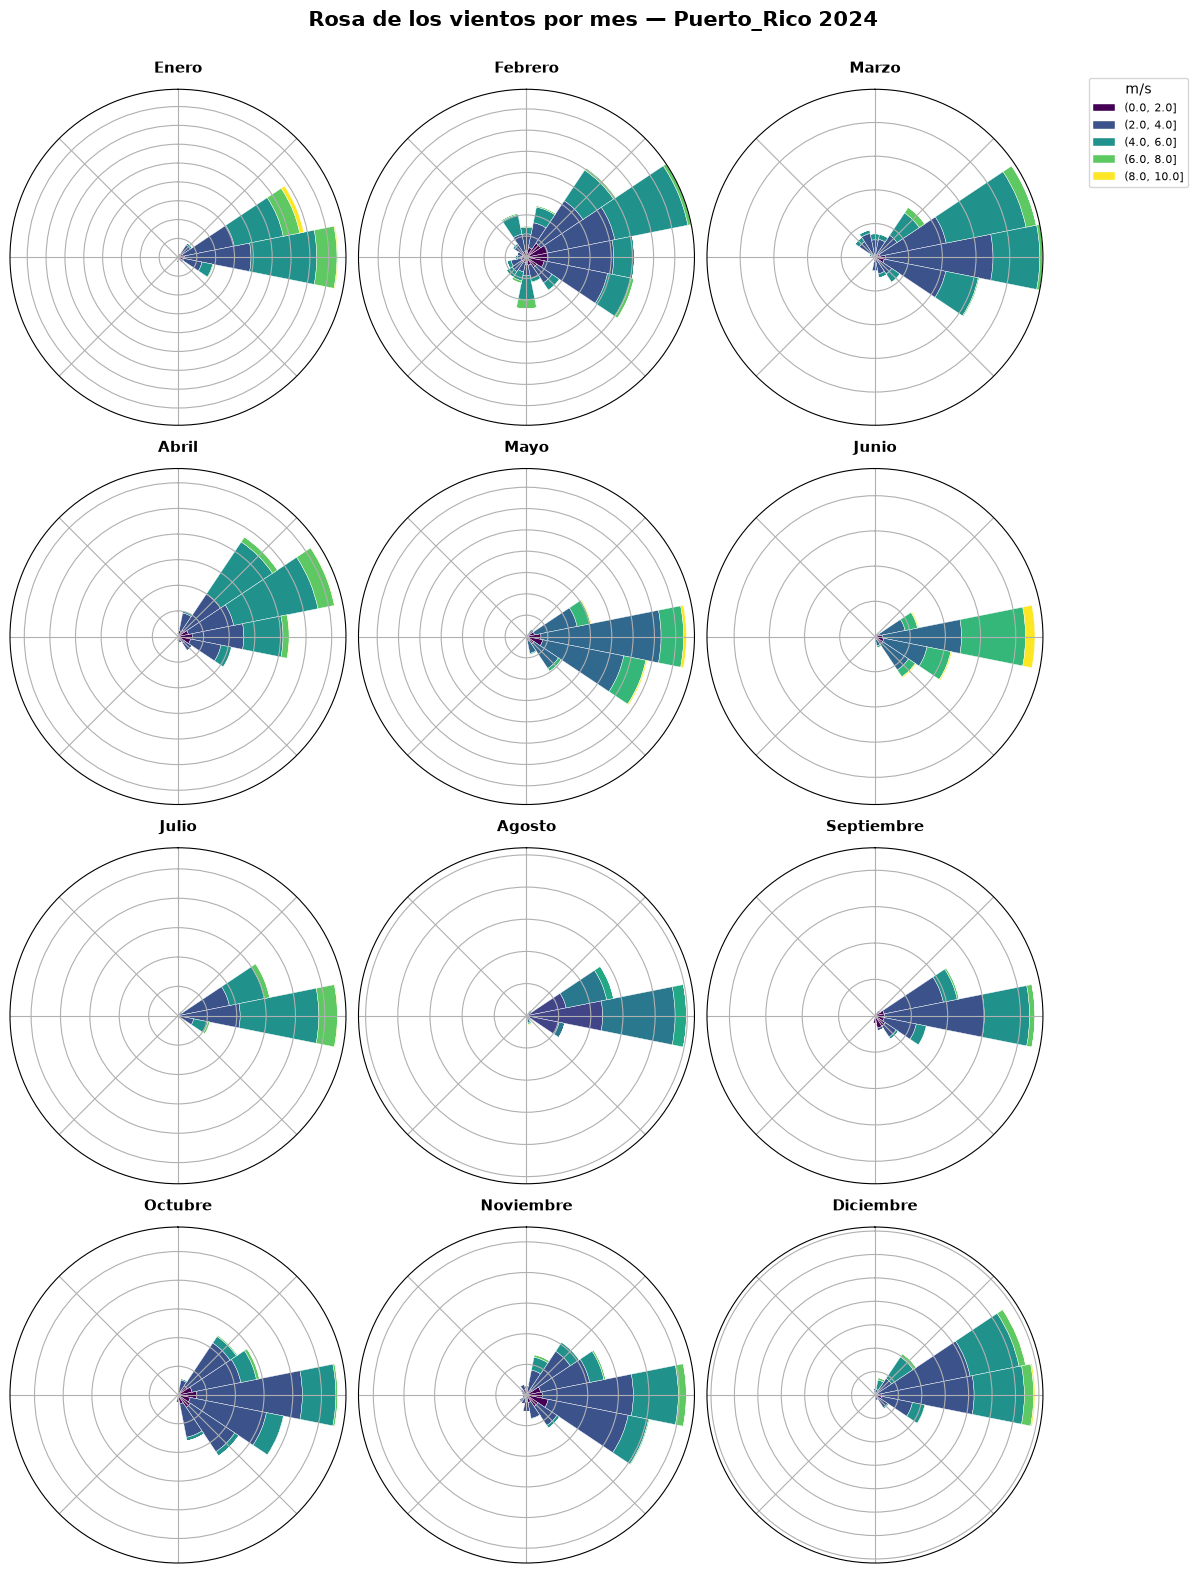

In [39]:
# Rosa de los vientos por mes (panel 4x3): muestra el ciclo estacional del viento.
a.rosa_viento_12meses()

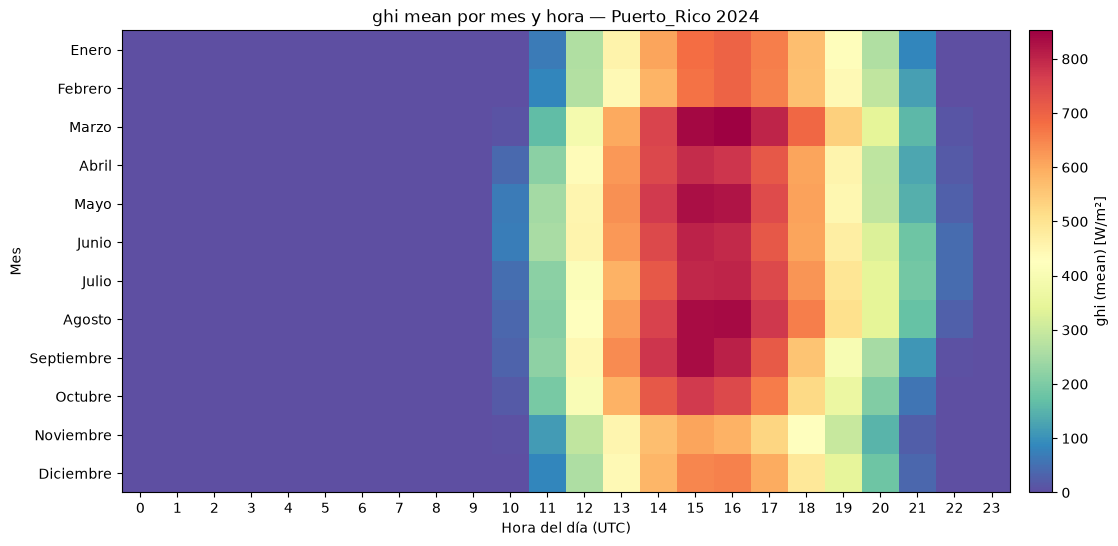

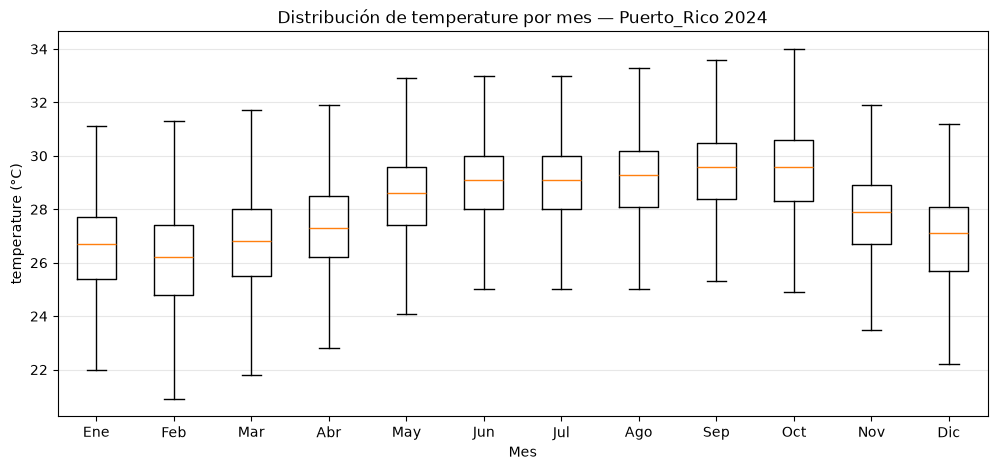

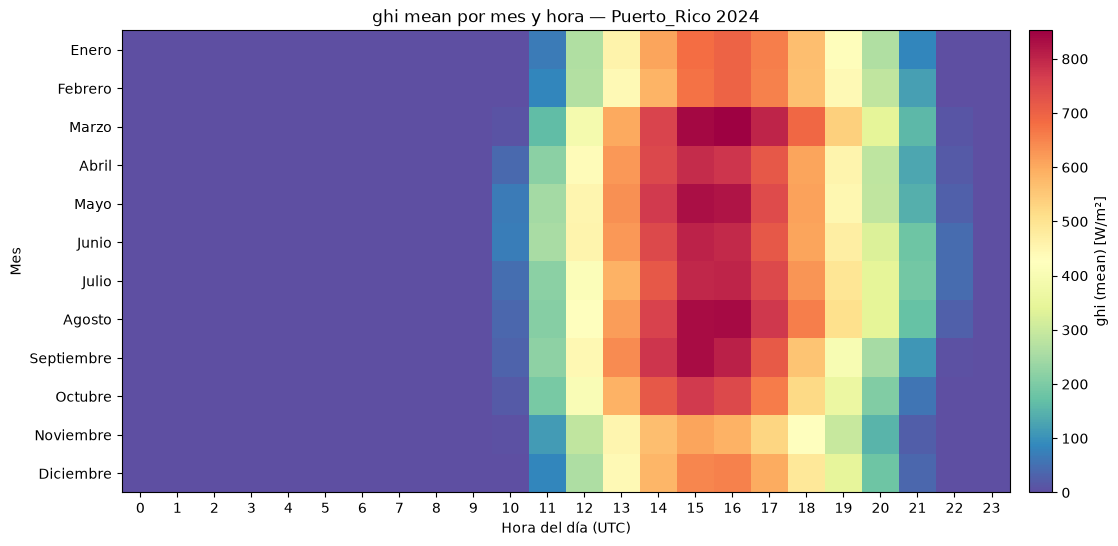

In [40]:
# Estacionalidad y ciclo diario:
a.boxplot('temperature', por='mes')      # dispersión de temperatura por mes
a.heatmap_mes_hora('ghi')                # GHI medio por mes (filas) y hora (columnas)

## 10. Mapas por nodo — recurso e inter-anual

Puente con `MapaEspacial`: pintan un valor por nodo sobre el mapa (con mapa base si está
instalado `contextily`; si no, se dibujan los puntos igualmente).

- `mapa_recurso(...)` → **insolación media diaria** (kWh/m²/día): el entregable de un atlas solar.
- `mapa_delta(otro_año, ...)` → **diferencia por nodo** entre dos años (escala divergente en 0).

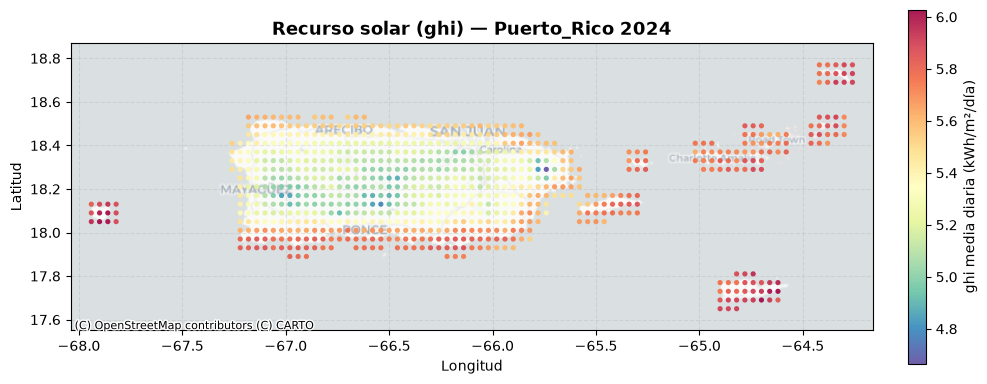

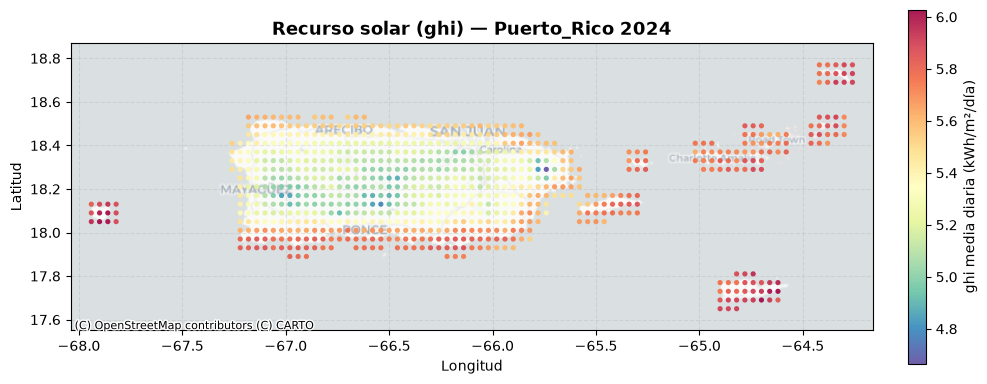

In [3]:
# Atlas del recurso solar: insolación media diaria por nodo (kWh/m²/día):
a.mapa_recurso('ghi')

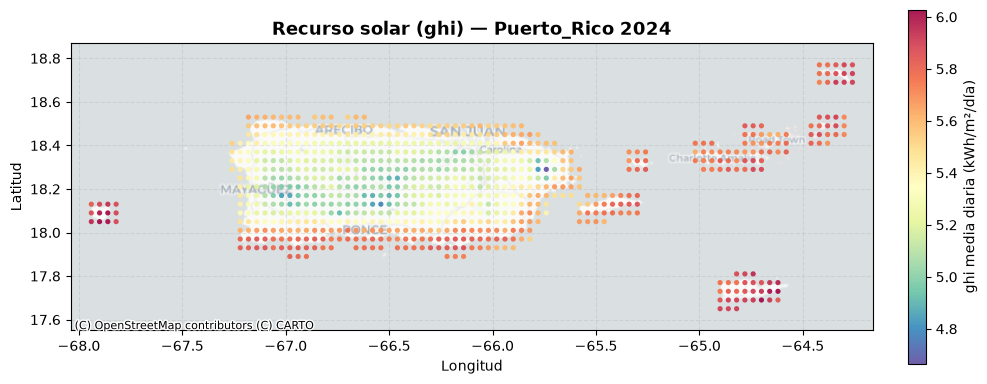

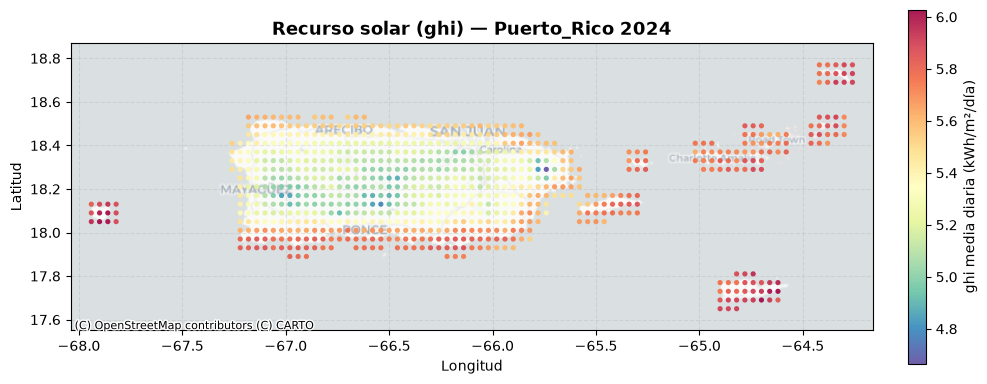

In [5]:
a.mapa_recurso('ghi')  # febrero

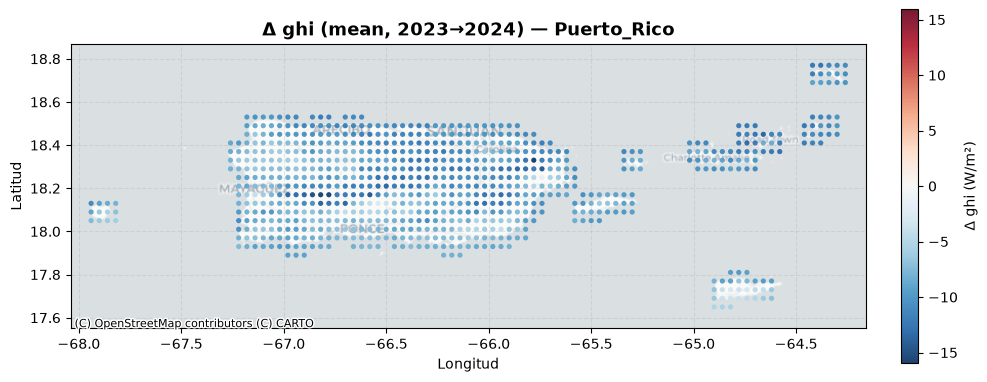

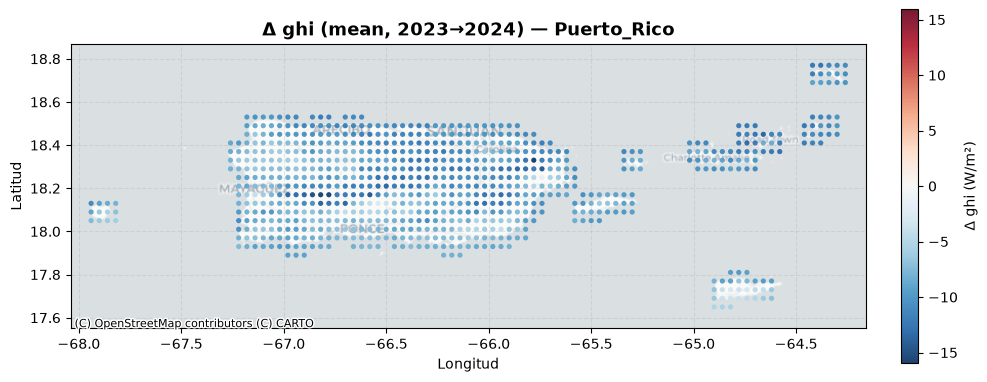

In [4]:
# Diferencia de GHI medio por nodo, 2024 vs 2023 (rojo = subió, azul = bajó):
a.mapa_delta(2023, variable='ghi')

## 11. Exportación — `exportar()`

Vuelca el subconjunto filtrado a CSV / Parquet / Excel / Feather. El formato se infiere por la
extensión. Acepta los mismos filtros que `filtrar` (incluido `columnas`, `con_kt`, `decodificar`).

In [30]:
# Ejemplo: exportar el 29-feb de unos nodos con kt incluido.
a.exportar('Results/Tamaulipas/sub_29feb_2024.csv',
           nodos=[0, 1, 2], dia='2024-02-29',
           columnas=['nodo_id', 'datetime', 'ghi', 'dni', 'kt'])

✅ exportado 72 filas × 5 cols -> Results/Tamaulipas/sub_29feb_2024.csv


'Results/Tamaulipas/sub_29feb_2024.csv'

## 12. Informe consolidado — `reporte()`

Empaqueta `info` + `integridad` + las gráficas clave en un solo documento **HTML**
(autocontenido) o **PDF** (una figura por página). El formato se infiere de la extensión.
Es pesado para el año completo; acota con filtros para vistas rápidas.

In [ ]:
# Informe acotado a febrero (rápido). Para el año completo: a.reporte('informe_2024.html')
a.reporte('Results/Tamaulipas/informe_feb_2024.html', mes=2)
# También en PDF (una figura por página):  a.reporte('informe_feb_2024.pdf', mes=2)

---
## Resumen

| Necesidad | Método |
|---|---|
| Ver el contenido | `info()`, `variables`, `nodos()` |
| Validar calidad | `integridad()`, `flags()`, `anomalias()` |
| Estadística | `estadisticas()`, `resumen_nodos()` |
| Subconjuntos | `filtrar()`, `decodificar()` |
| Recurso solar | `kt` (variable), `clasificar_dias()`, `resamplear()`, `curva_duracion()` |
| Gráficas | `histograma()`, `serie_temporal()`, `perfil_diario()`, `correlaciones()`, `boxplot()`, `heatmap_mes_hora()` |
| Viento / nodos atípicos | `rosa_viento()`, `rosa_viento_12meses()`, `outliers_nodos()` |
| Mapas por nodo | `mapa_recurso()`, `mapa_delta()` |
| Comparar años | `comparar()` |
| Informe / exportar | `reporte()`, `exportar()` |

Todo esto también está disponible por línea de comandos: ver `Utils/README_analizador.md`.